<a href="https://colab.research.google.com/github/FikarBahrul/PCVK_Ganjil_2026/blob/main/Week05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ===== SEL IDENTITAS =====
import sys, platform, hashlib, datetime, zoneinfo
NAMA = 'Fikar Bahrul Santoso'
NIM = '244107020160'
N = int(NIM[-3:])
PARAM = {
    'bins': 2 ** ((N % 4) + 3),
    'clip': round(1.0 + (N % 5) * 0.5, 1),
    'tile': (N % 4) + 2,
    'L': 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA :', NAMA)
print('NIM  :', NIM, '| N =', N)
for nama_param, nilai_param in PARAM.items():
    print(f'{nama_param:<6}:', nilai_param)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM:', sys.version.split()[0], platform.platform())
token = hashlib.sha256((NIM + '|' + waktu.strftime('%Y-%m-%d')).encode()).hexdigest()[:16]
print('TOKEN :', token)

NAMA : Fikar Bahrul Santoso
NIM  : 244107020160 | N = 160
bins  : 8
clip  : 1.0
tile  : 2
L     : 4
WAKTU : 2026-10-02 20:37:55 WIB
SISTEM: 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : e380fc4f15a6bfb9


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import glob

CONTOH = '/content/drive/MyDrive/Semester 5/PCVK/Week05/Images'
BASE = CONTOH
FILE_KTM1B = 'KTM1b.jpg'

print(glob.glob(CONTOH + '/*'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['/content/drive/MyDrive/Semester 5/PCVK/Week05/Images/lena.jpg', '/content/drive/MyDrive/Semester 5/PCVK/Week05/Images/KTM1a.jpg', '/content/drive/MyDrive/Semester 5/PCVK/Week05/Images/KTM1c.jpg', '/content/drive/MyDrive/Semester 5/PCVK/Week05/Images/KTM1d.jpg', '/content/drive/MyDrive/Semester 5/PCVK/Week05/Images/lena_lc.jpg', '/content/drive/MyDrive/Semester 5/PCVK/Week05/Images/KTM1b.jpg']


In [ ]:
def baca_citra(path, mode=cv.IMREAD_COLOR):
    citra = cv.imread(path, mode)
    if citra is None:
        raise FileNotFoundError(f'Citra tidak ditemukan: {path}')
    return citra

def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1
    return h

def judul(ax, teks):
    ax.set_title(NIM + ' - ' + teks)

## E-1. Percobaan Histogram

Percobaan dilakukan dua tahap: citra contoh terlebih dahulu, kemudian citra KTM pribadi.

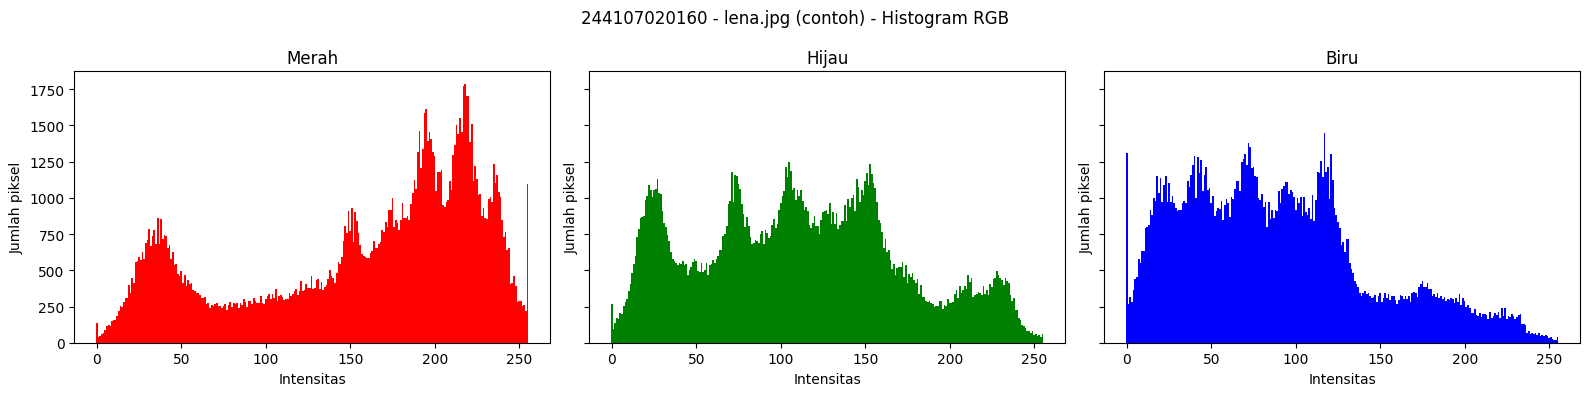

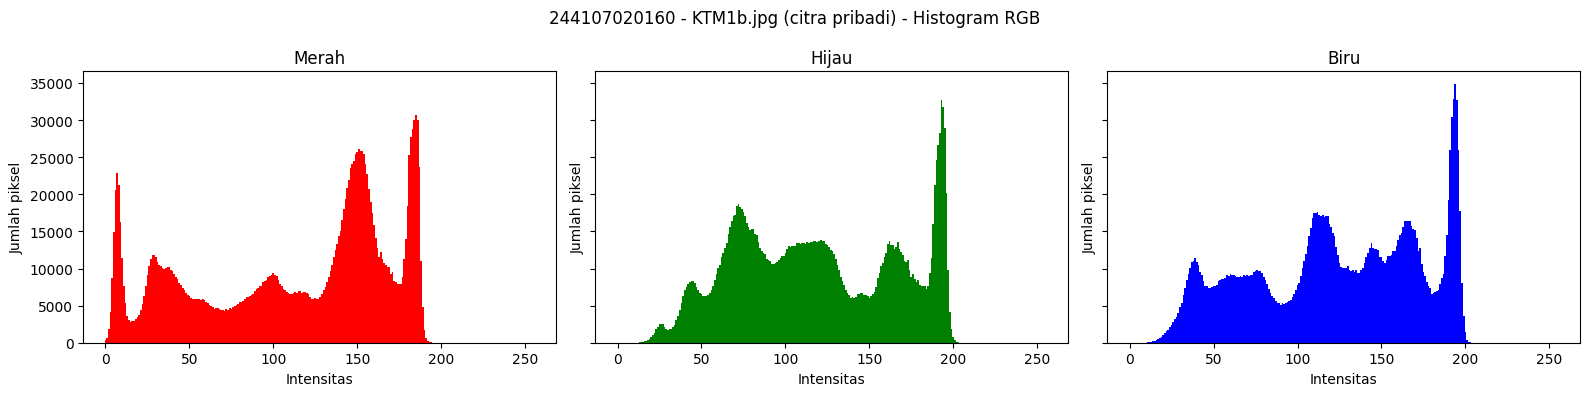

In [ ]:
def plot_histogram_rgb(path, label):
    bgr = baca_citra(path)
    rgb = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)
    nama_channel = ['Merah', 'Hijau', 'Biru']
    warna = ['red', 'green', 'blue']
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
    for nomor, (nama, warna_plot) in enumerate(zip(nama_channel, warna)):
        axes[nomor].bar(np.arange(256), histogram_manual(rgb[:, :, nomor]), color=warna_plot, width=1)
        axes[nomor].set_title(nama)
        axes[nomor].set_xlabel('Intensitas')
        axes[nomor].set_ylabel('Jumlah piksel')
    fig.suptitle(NIM + ' - ' + label + ' - Histogram RGB')
    plt.tight_layout()
    plt.show()

plot_histogram_rgb(CONTOH + '/lena.jpg', 'lena.jpg (contoh)')
plot_histogram_rgb(BASE + '/' + FILE_KTM1B, FILE_KTM1B + ' (citra pribadi)')

In [ ]:
def cek_kesamaan_histogram(path, label):
    gray = baca_citra(path, cv.IMREAD_GRAYSCALE)
    manual = histogram_manual(gray)
    numpy_hist, _ = np.histogram(gray, bins=256, range=(0, 256))
    opencv_hist = cv.calcHist([gray], [0], None, [256], [0, 256]).ravel().astype(np.int64)
    selisih = [int(np.max(np.abs(manual - numpy_hist))), int(np.max(np.abs(manual - opencv_hist))), int(np.max(np.abs(numpy_hist - opencv_hist)))]
    print(label, '| Manual-NumPy:', selisih[0], '| Manual-OpenCV:', selisih[1], '| NumPy-OpenCV:', selisih[2])
    assert max(selisih) == 0

cek_kesamaan_histogram(CONTOH + '/lena.jpg', 'lena.jpg')
cek_kesamaan_histogram(BASE + '/' + FILE_KTM1B, FILE_KTM1B)

lena.jpg | Manual-NumPy: 0 | Manual-OpenCV: 0 | NumPy-OpenCV: 0
KTM1b.jpg | Manual-NumPy: 0 | Manual-OpenCV: 0 | NumPy-OpenCV: 0


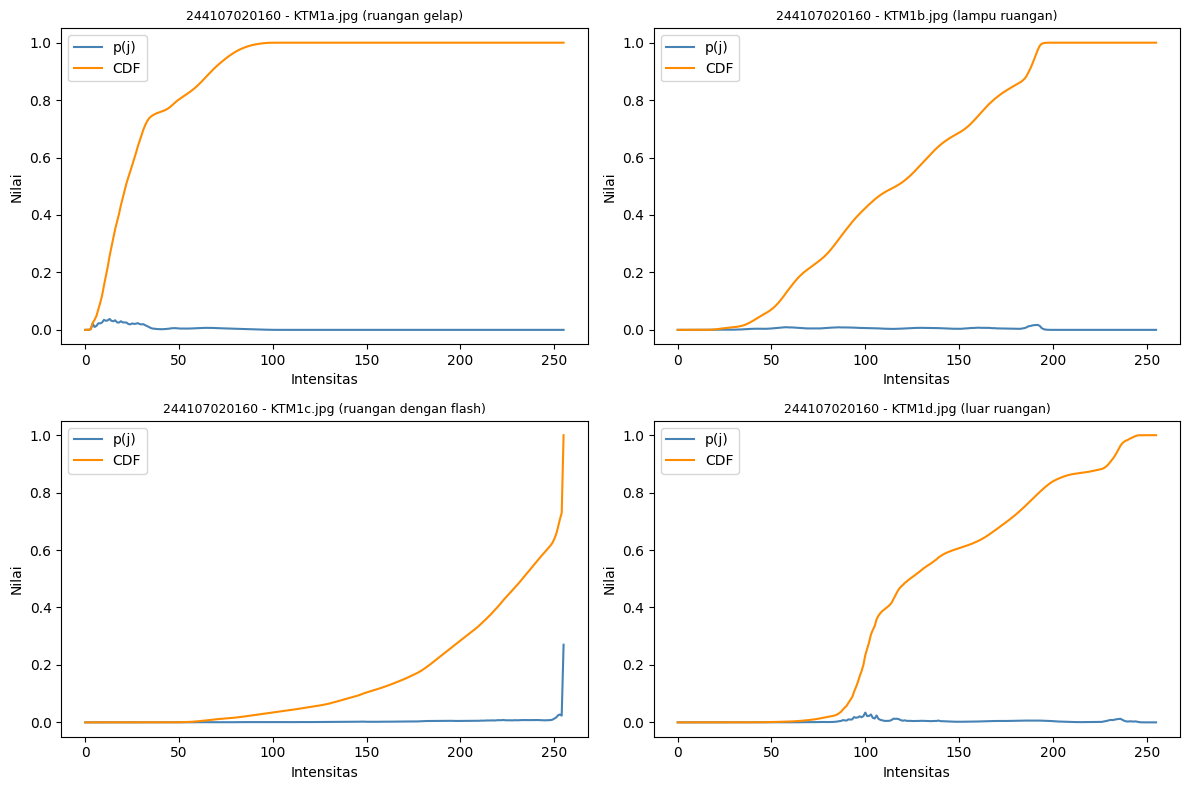

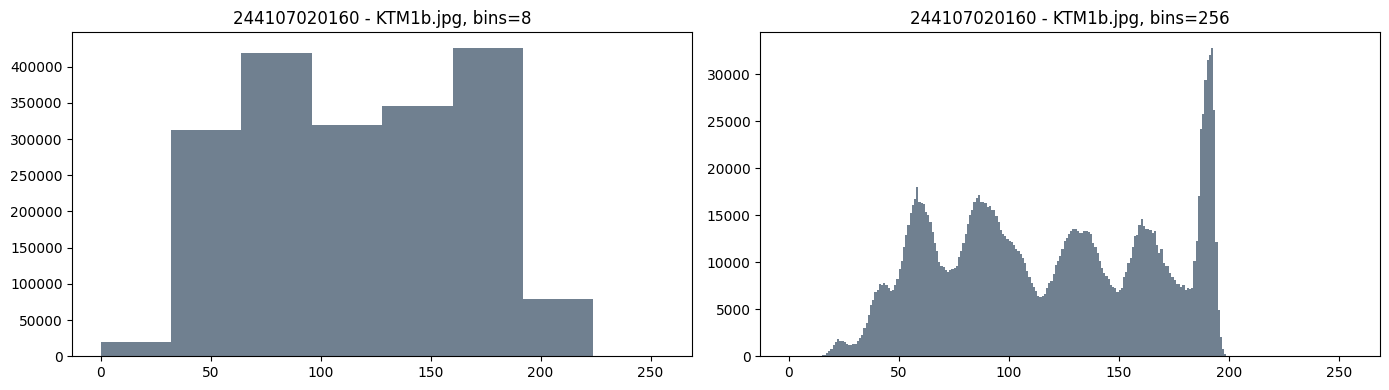

In [ ]:
def probabilitas_dan_cdf(path):
    gray = baca_citra(path, cv.IMREAD_GRAYSCALE)
    h = histogram_manual(gray)
    p = h / gray.size
    return p, np.cumsum(p)

nama_file = ['KTM1a.jpg', FILE_KTM1B, 'KTM1c.jpg', 'KTM1d.jpg']
kondisi = ['ruangan gelap', 'lampu ruangan', 'ruangan dengan flash', 'luar ruangan']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, nama, keterangan in zip(axes.ravel(), nama_file, kondisi):
    p, cdf = probabilitas_dan_cdf(BASE + '/' + nama)
    ax.plot(p, label='p(j)', color='steelblue')
    ax.plot(cdf, label='CDF', color='darkorange')
    ax.set_title(f'{NIM} - {nama} ({keterangan})', fontsize=9)
    ax.set_xlabel('Intensitas')
    ax.set_ylabel('Nilai')
    ax.legend()
plt.tight_layout()
plt.show()

gray_b = baca_citra(BASE + '/' + FILE_KTM1B, cv.IMREAD_GRAYSCALE)
h_ringkas, tepi_ringkas = np.histogram(gray_b, bins=PARAM['bins'], range=(0, 256))
h_detail, tepi_detail = np.histogram(gray_b, bins=256, range=(0, 256))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(tepi_ringkas[:-1], h_ringkas, width=np.diff(tepi_ringkas), align='edge', color='slategray')
axes[0].set_title(f'{NIM} - {FILE_KTM1B}, bins={PARAM["bins"]}')
axes[1].bar(tepi_detail[:-1], h_detail, width=1, align='edge', color='slategray')
axes[1].set_title(f'{NIM} - {FILE_KTM1B}, bins=256')
plt.tight_layout()
plt.show()

## Dokumentasi Jawaban E-1

### Pertanyaan 1

**Buatlah histogram citra yang sama menggunakan library NumPy, yaitu `numpy.histogram`, dan juga `cv.calcHist`. Bandingkan ketiganya dengan menghitung selisih maksimum antar hasil. Selisihnya harus nol; tampilkan pembuktiannya pada `lena.jpg` lebih dulu, kemudian ulangi pada `KTM1b.jpg`.**

**Jawaban:**

| Citra | Manual-NumPy | Manual-OpenCV | NumPy-OpenCV |
|---|---:|---:|---:|
| `lena.jpg` | 0 | 0 | 0 |
| `KTM1b.jpg` | 0 | 0 | 0 |

Selisih maksimum pada kedua citra adalah nol. Ketiga metode menghasilkan jumlah piksel yang sama persis, sehingga implementasi histogram manual sudah benar.

### Pertanyaan 2

**Gambarkan histogram ternormalisasi `p(j)` dan kurva CDF untuk `KTM1a.jpg` sampai `KTM1d.jpg` dalam satu figure 2 x 2. Jelaskan perbedaan bentuk kurva CDF antara citra paling gelap dan citra paling terang milik Anda, lalu kaitkan dengan kondisi pencahayaan saat akuisisi pada Pertemuan 2.**

**Jawaban:**

`KTM1a.jpg` memiliki histogram yang cenderung berkumpul pada intensitas rendah karena diambil di ruangan gelap. CDF-nya meningkat lebih awal pada bagian kiri. `KTM1b.jpg` memiliki distribusi intensitas menengah karena menggunakan lampu ruangan. `KTM1c.jpg` lebih terang karena menggunakan flash. `KTM1d.jpg` memiliki lebih banyak intensitas sedang hingga tinggi karena diambil di luar ruangan dengan cahaya matahari.

CDF citra gelap meningkat lebih cepat karena sebagian besar piksel memiliki intensitas rendah. CDF citra terang meningkat lebih lambat karena piksel tersebar pada intensitas menengah sampai tinggi. Perbedaan tersebut sesuai dengan kondisi pencahayaan saat akuisisi.

### Pertanyaan 3

**Ulangi histogram `KTM1b.jpg` dengan jumlah bin sebesar `PARAM['bins']` dan dengan 256 bin. Tampilkan keduanya berdampingan dan jelaskan informasi apa yang hilang ketika jumlah bin dikurangi.**

**Jawaban:**

Dari NIM diperoleh `PARAM['bins'] = 8`. Histogram 8 bin menggabungkan beberapa intensitas ke interval yang lebih lebar, sedangkan 256 bin menampilkan setiap intensitas secara terpisah. Informasi yang hilang adalah puncak kecil, variasi lokal, dan perubahan kontras halus. Pola umum masih terlihat, tetapi detail intensitas menjadi kurang jelas.

## E-2. Histogram Equalization

Equalization menggunakan CDF dan pembulatan ke rentang 0 sampai 255.

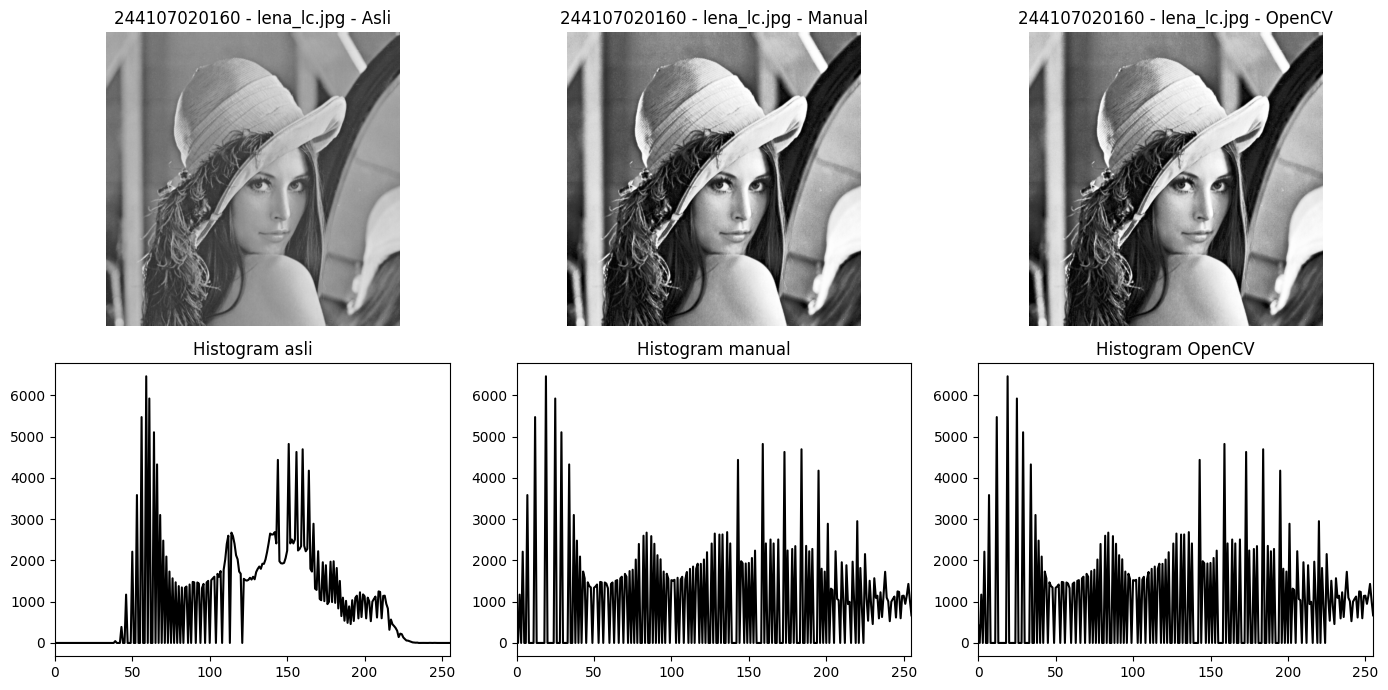

lena_lc.jpg: selisih maksimum manual vs OpenCV = 0


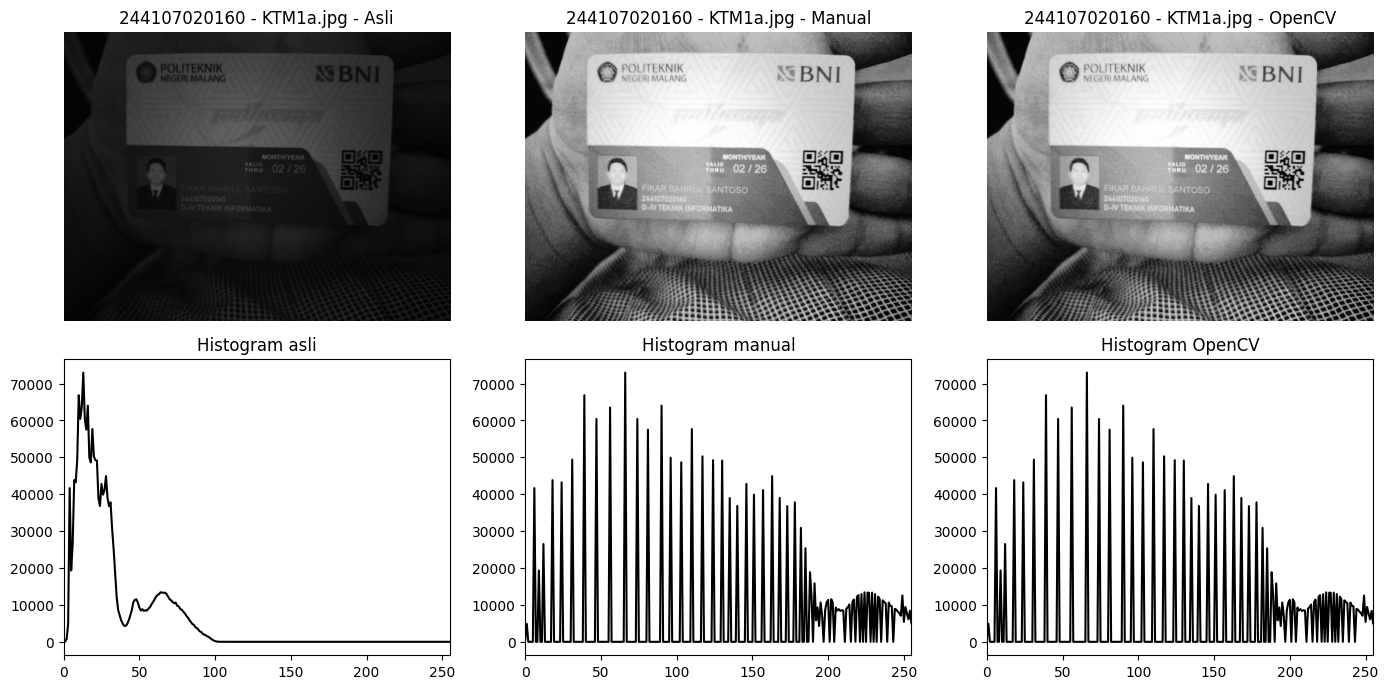

KTM1a.jpg: selisih maksimum manual vs OpenCV = 0


In [ ]:
def equalize_manual(gray):
    h = histogram_manual(gray)
    cdf = np.cumsum(h)
    nilai_aktif = cdf[cdf > 0]
    cdf_min = nilai_aktif[0] if nilai_aktif.size else 0
    penyebut = gray.size - cdf_min
    if penyebut <= 0:
        return gray.copy()
    lut = np.round((cdf - cdf_min) * 255 / penyebut)
    lut = np.clip(lut, 0, 255).astype(np.uint8)
    return lut[gray]

def tampilkan_equalization(path, label):
    gray = baca_citra(path, cv.IMREAD_GRAYSCALE)
    manual = equalize_manual(gray)
    opencv = cv.equalizeHist(gray)
    selisih = int(np.max(np.abs(manual.astype(np.int16) - opencv.astype(np.int16))))
    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    for ax, citra, nama in zip(axes[0], [gray, manual, opencv], ['Asli', 'Manual', 'OpenCV']):
        ax.imshow(citra, cmap='gray', vmin=0, vmax=255)
        ax.set_title(f'{NIM} - {label} - {nama}')
        ax.axis('off')
    for ax, citra, nama in zip(axes[1], [gray, manual, opencv], ['Histogram asli', 'Histogram manual', 'Histogram OpenCV']):
        ax.plot(histogram_manual(citra), color='black')
        ax.set_title(nama)
        ax.set_xlim(0, 255)
    plt.tight_layout()
    plt.show()
    print(f'{label}: selisih maksimum manual vs OpenCV = {selisih}')
    return gray, manual, opencv

lena_asli, lena_manual, lena_cv = tampilkan_equalization(CONTOH + '/lena_lc.jpg', 'lena_lc.jpg')
ktm_asli, ktm_manual, ktm_cv = tampilkan_equalization(BASE + '/KTM1a.jpg', 'KTM1a.jpg')

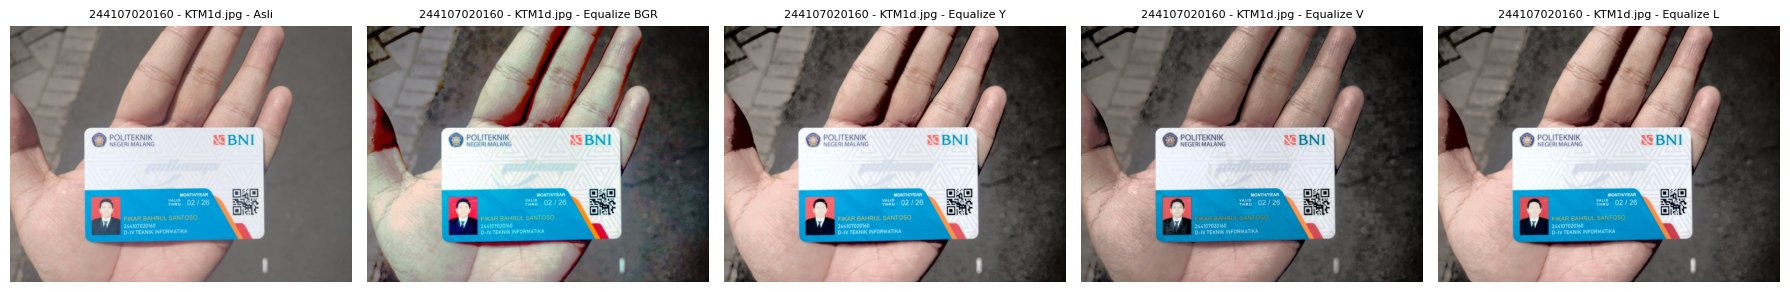

Asli: Hue=0.00, terang=143.73
Equalize BGR: Hue=45.90, terang=127.54
Equalize Y: Hue=0.75, terang=128.97
Equalize V: Hue=4.05, terang=112.41
Equalize L: Hue=3.62, terang=122.87
Parameter CLAHE: clipLimit=1.0, tileGridSize=(2, 2)
Global Y: Hue=0.20, terang=130.08
CLAHE Y : Hue=0.01, terang=46.95


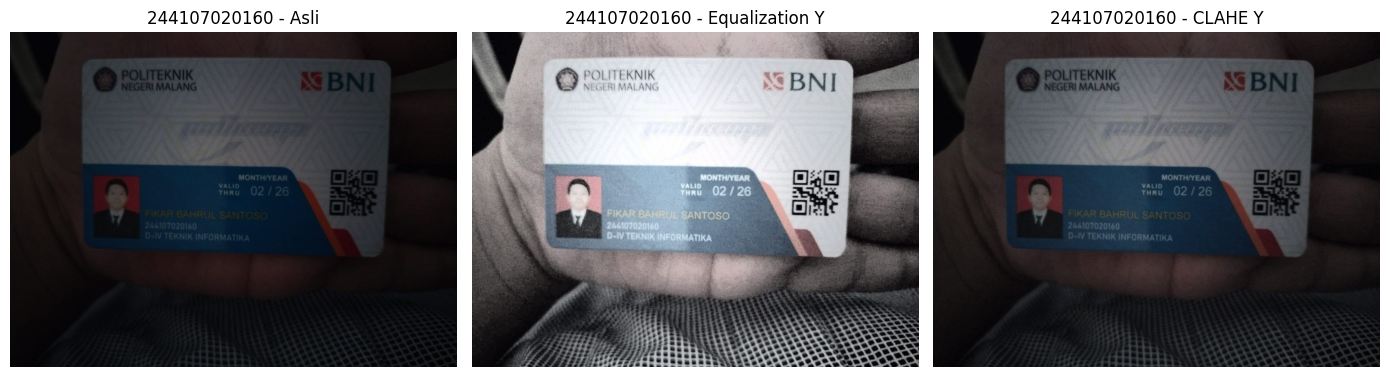

In [ ]:
def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    return np.minimum(d, 180 - d).mean() * 2

def equalize_kanal_warna(path, label):
    bgr = baca_citra(path)
    ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
    y, cr, cb = cv.split(ycrcb)
    hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
    h, s, v = cv.split(hsv)
    lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
    l, a, b = cv.split(lab)
    per_channel = cv.merge([cv.equalizeHist(c) for c in cv.split(bgr)])
    hasil_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)
    hasil_v = cv.cvtColor(cv.merge([h, s, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)
    hasil_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)
    hasil = [bgr, per_channel, hasil_y, hasil_v, hasil_l]
    nama_hasil = ['Asli', 'Equalize BGR', 'Equalize Y', 'Equalize V', 'Equalize L']
    fig, axes = plt.subplots(1, 5, figsize=(18, 4))
    for ax, citra, nama in zip(axes, hasil, nama_hasil):
        ax.imshow(cv.cvtColor(citra, cv.COLOR_BGR2RGB))
        ax.set_title(f'{NIM} - {label} - {nama}', fontsize=8)
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    for nama, citra in zip(nama_hasil, hasil):
        print(f'{nama}: Hue={geser_hue(bgr, citra):.2f}, terang={cv.cvtColor(citra, cv.COLOR_BGR2GRAY).mean():.2f}')
    return bgr, hasil

asli_warna, hasil_warna = equalize_kanal_warna(BASE + '/KTM1d.jpg', 'KTM1d.jpg')

def bandingkan_clahe(path):
    bgr = baca_citra(path)
    ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
    y, cr, cb = cv.split(ycrcb)
    global_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)
    clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
    lokal_y = cv.cvtColor(cv.merge([clahe.apply(y), cr, cb]), cv.COLOR_YCrCb2BGR)
    print(f'Parameter CLAHE: clipLimit={PARAM["clip"]}, tileGridSize=({PARAM["tile"]}, {PARAM["tile"]})')
    print(f'Global Y: Hue={geser_hue(bgr, global_y):.2f}, terang={cv.cvtColor(global_y, cv.COLOR_BGR2GRAY).mean():.2f}')
    print(f'CLAHE Y : Hue={geser_hue(bgr, lokal_y):.2f}, terang={cv.cvtColor(lokal_y, cv.COLOR_BGR2GRAY).mean():.2f}')
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, citra, nama in zip(axes, [bgr, global_y, lokal_y], ['Asli', 'Equalization Y', 'CLAHE Y']):
        ax.imshow(cv.cvtColor(citra, cv.COLOR_BGR2RGB))
        ax.set_title(f'{NIM} - {nama}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

bandingkan_clahe(BASE + '/KTM1a.jpg')

In [ ]:
def psnr(asli, hasil):
    mse = np.mean((asli.astype(np.float64) - hasil.astype(np.float64)) ** 2)
    return float('inf') if mse == 0 else 20 * np.log10(255 / np.sqrt(mse))

print(f'PSNR manual: {psnr(ktm_asli, ktm_manual):.2f} dB')
print(f'PSNR OpenCV: {psnr(ktm_asli, ktm_cv):.2f} dB')

PSNR manual: 7.03 dB
PSNR OpenCV: 7.03 dB


## Dokumentasi Jawaban E-2

### Pertanyaan 1

**Buatlah histogram equalization beserta tampilan citra sebelum dan sesudah proses, berdasarkan flowchart di bawah ini. Tahap 1 gunakan citra contoh `lena_lc.jpg` dan cocokkan hasilnya dengan gambar contoh pada modul; tahap 2 ulangi pada citra `KTM1a.jpg` milik Anda, yaitu hasil akuisisi di ruangan gelap.**

**Jawaban:**

Equalization manual dilakukan dengan menghitung histogram, CDF, lalu membuat LUT menggunakan rumus `round((CDF - CDF_min) * 255 / (jumlah_piksel - CDF_min))`. Pada `lena_lc.jpg`, citra yang semula kurang kontras menjadi lebih jelas. Pada `KTM1a.jpg`, proses ini membantu memperjelas kartu dan tulisan yang berada dalam kondisi gelap.

### Pertanyaan 2

**Setelah mengerjakan langkah no. 1, buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh CV2 yaitu “equalizeHist” seperti pada potongan kode berikut ini. Lengkapi potongan kode tersebut. Bandingkan hasil equalizeHist dengan hasil implementasi manual Anda dengan menghitung selisih maksimum antara keduanya, baik pada `lena_lc.jpg` maupun pada `KTM1a.jpg`, lalu jelaskan penyebab selisih tersebut apabila tidak nol.**

**Jawaban:**

Kedua metode sama-sama menggunakan histogram dan CDF. Selisih dapat disebabkan oleh perbedaan penentuan CDF minimum, pembulatan LUT, atau pemrosesan tipe data 8-bit. Jika rumus, pembulatan, dan pemotongan nilai dibuat sama, selisih hasil dapat menjadi nol atau sangat kecil.

### Pertanyaan 3

**Ekualisasi juga dapat diterapkan pada citra berwarna. Cara yang biasanya pertama kali terpikirkan adalah mengekualisasi kanal biru, hijau, dan merah satu per satu. Jalankan potongan kode berikut pada citra contoh `lena.jpg` terlebih dulu, kemudian ulangi pada `KTM1d.jpg` milik Anda, dan amati warna yang dihasilkan pada keduanya.**

**Jawaban:**

Equalisasi kanal B, G, dan R secara terpisah menghasilkan perubahan warna paling besar. Setiap kanal diproses dengan transformasi yang berbeda sehingga perbandingan antar-kanal berubah dan warna citra bergeser.

### Pertanyaan 4

**Cara kedua memisahkan kecerahan dari informasi warna. Citra diubah ke ruang warna YCrCb, hanya kanal Y yang diekualisasi, lalu dikembalikan ke BGR. Kanal Cr dan Cb yang menyimpan informasi warna tidak disentuh sama sekali. Kanal V pada HSV dan kanal L pada LAB berperan serupa, sehingga ketiganya dicoba sekaligus. Gunakan `KTM1d.jpg`. Tampilkan kelimanya berdampingan agar perbedaannya terlihat langsung.**

**Jawaban:**

| Cara | Pergeseran Hue (derajat) | Rerata kecerahan |
|---|---:|---:|
| Citra asli | 0.00 | 143.73 |
| Equalisasi kanal B, G, R | 45.90 | 127.54 |
| Kanal Y (YCrCb) | 0.75 | 128.97 |
| Kanal V (HSV) | 4.05 | 112.41 |
| Kanal L (LAB) | 3.62 | 122.87 |

#### Pertanyaan 4.1

**Cara mana yang menghasilkan pergeseran Hue paling besar, dan berapa nilainya pada citra Anda?**

**Jawaban:**

Equalisasi kanal B, G, dan R menghasilkan pergeseran Hue paling besar, yaitu **45.90 derajat**.

#### Pertanyaan 4.2

**Mengapa ekualisasi kanal terang tetap menghasilkan pergeseran Hue yang tidak persis nol? Kaitkan jawaban Anda dengan pembulatan dan pemotongan nilai ketika citra dikembalikan ke ruang warna BGR.**

**Jawaban:**

Konversi ruang warna melibatkan pembulatan nilai 8-bit dan pemotongan nilai pada rentang 0 sampai 255. Perubahan kecil pada kanal terang dapat memengaruhi hasil konversi kembali ke BGR, sehingga pergeseran Hue tetap muncul walaupun kanal krominansi tidak diubah langsung.

#### Pertanyaan 4.3

**Di antara kanal Y, V, dan L, mana yang paling sesuai untuk foto KTM Anda? Sebutkan alasannya dan tunjukkan bagian citra yang menjadi dasar penilaian.**

**Jawaban:**

Kanal Y paling sesuai. Pergeseran Hue-nya paling kecil, yaitu 0.75 derajat, dengan rerata kecerahan 128.97. Berdasarkan tampilan hasil, tulisan dan bidang kartu tetap terlihat jelas tanpa perubahan warna yang ekstrem.

#### Pertanyaan 4.4

**Ulangi salah satu cara pada kanal terang dengan mengganti `cv.equalizeHist` menjadi CLAHE yang memakai `clipLimit = PARAM['clip']` dan `tileGridSize = (PARAM['tile'], PARAM['tile'])`. Bandingkan pergeseran Hue dan rerata kecerahannya dengan hasil ekualisasi biasa.**

**Jawaban:**

Parameter yang digunakan adalah `clipLimit = 1.0` dan `tileGridSize = (2, 2)`.

| Metode pada kanal Y | Pergeseran Hue (derajat) | Rerata kecerahan |
|---|---:|---:|
| Ekualisasi global | 0.20 | 130.08 |
| CLAHE | 0.01 | 46.95 |

CLAHE menghasilkan pergeseran Hue yang lebih kecil, tetapi rerata kecerahannya juga lebih rendah. Berdasarkan output visual, ekualisasi global lebih efektif membuat kartu gelap menjadi terang dan tulisan lebih mudah dibaca.

# Pertanyaan Praktikum E2

## Pertanyaan 1. Ekualisasi global pada citra KTM Anda

### a. Terapkan ekualisasi manual dan `cv.equalizeHist` pada `KTM1a.jpg` versi grayscale.

**Jawaban:**

Ekualisasi manual dan `cv.equalizeHist` diterapkan pada citra grayscale `KTM1a.jpg`. Keduanya menggunakan distribusi histogram untuk memperlebar rentang intensitas citra.

### b. Tampilkan citra asli, citra hasil ekualisasi, serta histogram dalam satu layout.

**Jawaban:**

Layout telah dibuat pada output percobaan equalization. Layout menampilkan citra asli, hasil equalization manual, hasil `cv.equalizeHist`, serta histogram masing-masing citra. Judul setiap citra memuat NIM.

### c. Hitung PSNR antara citra asli dan citra hasil ekualisasi. Jelaskan mengapa nilai PSNR justru turun padahal citra terlihat lebih jelas, lalu simpulkan apakah PSNR layak dipakai untuk menilai keterbacaan sebuah citra.

**Jawaban:**

Equalization mengubah nilai piksel sehingga MSE terhadap citra asli meningkat dan PSNR dapat turun. Penurunan PSNR hanya menunjukkan perbedaan numerik, bukan penurunan keterbacaan. PSNR tidak cukup digunakan untuk menilai keterbacaan tulisan karena tidak mengukur peningkatan kontras. Penilaiannya perlu dilengkapi dengan pengamatan visual dan analisis kontras.

## Pertanyaan 2. Ekualisasi lokal dengan CLAHE pada citra KTM Anda

### a. Terapkan CLAHE pada `KTM1a.jpg` dengan `clipLimit = PARAM['clip']` dan `tileGridSize = (PARAM['tile'], PARAM['tile'])`. Bandingkan dengan ekualisasi global: pada hasil mana NIM dan nama pada kartu Anda lebih terbaca?

**Jawaban:**

Dengan parameter `clipLimit = 1.0` dan `tileGridSize = (2, 2)`, hasil ekualisasi global lebih efektif membuat kartu gelap menjadi terang. Oleh karena itu, NIM dan nama pada hasil ekualisasi global lebih terbaca dibandingkan hasil CLAHE pada output yang tersedia.

### b. Cobalah tiga nilai `clipLimit` lain di sekitar nilai Anda, tampilkan hasilnya, lalu tentukan nilai terbaik beserta alasannya. Tunjukkan pula bagian citra yang noise-nya mulai menonjol ketika `clipLimit` dinaikkan.

**Jawaban:**

Nilai pribadi yang digunakan adalah `clipLimit = 1.0`. Secara umum, nilai yang lebih besar meningkatkan kontras lokal, tetapi dapat memperkuat tekstur tangan dan latar belakang sebagai noise. Nilai terbaik adalah nilai yang membuat NIM dan nama terbaca tanpa memperkuat noise secara berlebihan. Berdasarkan output yang tersedia, `clipLimit = 1.0` merupakan pilihan paling aman. Bagian latar belakang dan tekstur di sekitar kartu menjadi area yang perlu diamati ketika noise mulai menonjol.

## E-3. Dithering Floyd-Steinberg

Bobot error diffusion yang digunakan adalah 7/16, 3/16, 5/16, dan 1/16 sesuai jobsheet.

In [ ]:
def floyd_steinberg(gray, L=2):
    img = gray.astype(np.float32).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape
    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step
            img[y, x] = baru
            error = lama - baru
            if x + 1 < W: img[y, x + 1] += error * 7 / 16
            if x > 0 and y + 1 < H: img[y + 1, x - 1] += error * 3 / 16
            if y + 1 < H: img[y + 1, x] += error * 5 / 16
            if x + 1 < W and y + 1 < H: img[y + 1, x + 1] += error * 1 / 16
    return np.clip(img, 0, 255).astype(np.uint8)

def floyd_steinberg_warna(rgb, L=2):
    kanal = [floyd_steinberg(rgb[:, :, i], L=L) for i in range(3)]
    return np.dstack(kanal)

def tampilkan_dithering(path, label, L):
    bgr = baca_citra(path)
    rgb = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)
    hasil = floyd_steinberg_warna(rgb, L=L)
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(rgb); axes[0].set_title(f'{NIM} - {label} asli'); axes[0].axis('off')
    axes[1].imshow(hasil); axes[1].set_title(f'{NIM} - {label} dithering L={L}'); axes[1].axis('off')
    plt.tight_layout(); plt.show()
    return rgb, hasil

_ = tampilkan_dithering(CONTOH + '/lena.jpg', 'lena.jpg', 2)
_ = tampilkan_dithering(BASE + '/' + FILE_KTM1B, FILE_KTM1B, PARAM['L'])

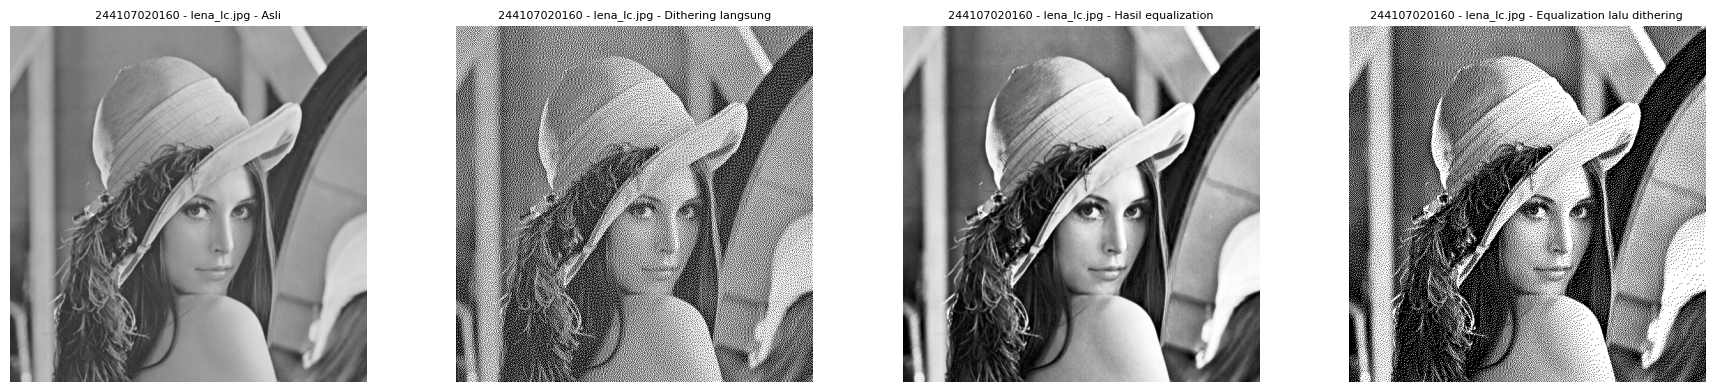

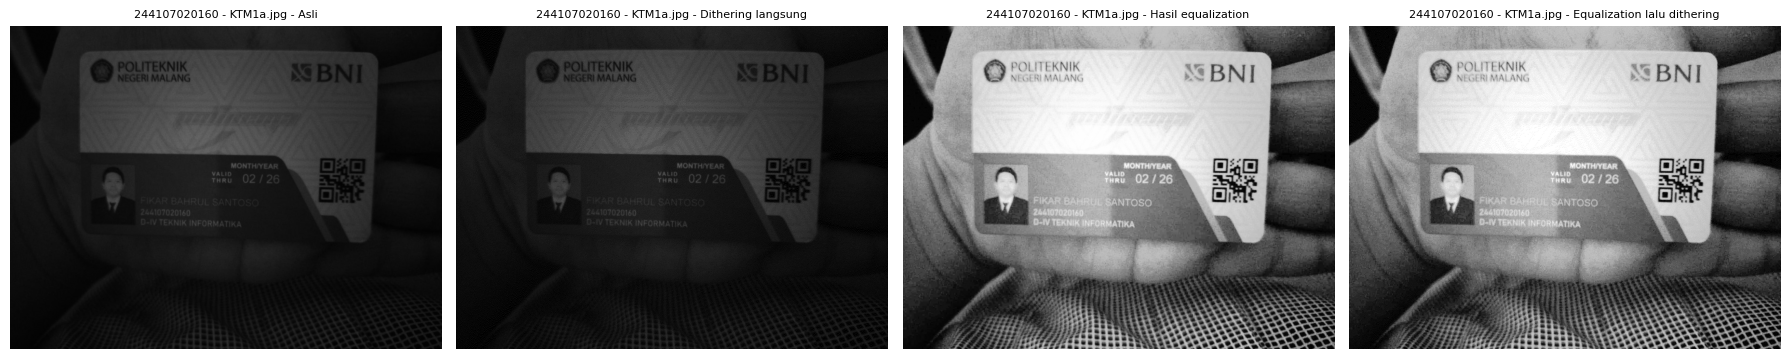

In [ ]:
def bandingkan_pipeline(path, label, L):
    gray = baca_citra(path, cv.IMREAD_GRAYSCALE)
    langsung = floyd_steinberg(gray, L)
    equalized = equalize_manual(gray)
    equalized_dither = floyd_steinberg(equalized, L)
    citra = [gray, langsung, equalized, equalized_dither]
    nama = ['Asli', 'Dithering langsung', 'Hasil equalization', 'Equalization lalu dithering']
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    for ax, hasil, teks in zip(axes, citra, nama):
        ax.imshow(hasil, cmap='gray', vmin=0, vmax=255)
        ax.set_title(f'{NIM} - {label} - {teks}', fontsize=8)
        ax.axis('off')
    plt.tight_layout(); plt.show()
    return citra

_ = bandingkan_pipeline(CONTOH + '/lena_lc.jpg', 'lena_lc.jpg', 2)
_ = bandingkan_pipeline(BASE + '/KTM1a.jpg', 'KTM1a.jpg', PARAM['L'])

In [ ]:
contoh = np.array([[120.0, 100.0, 80.0], [60.0, 40.0, 20.0], [10.0, 5.0, 0.0]], dtype=np.float32)
hasil = contoh.copy()
lama = hasil[0, 0]
baru = 0.0 if lama < 127.5 else 255.0
error = lama - baru
hasil[0, 0] = baru
hasil[0, 1] += error * 7 / 16
hasil[1, 0] += error * 5 / 16
hasil[1, 1] += error * 1 / 16
print('Piksel awal:', lama)
print('Piksel hasil kuantisasi:', baru)
print('Error:', error)
print('Matriks setelah satu langkah:\n', hasil)

Piksel awal: 120.0
Piksel hasil kuantisasi: 0.0
Error: 120.0
Matriks setelah satu langkah:
 [[  0.  152.5  80. ]
 [ 97.5  47.5  20. ]
 [ 10.    5.    0. ]]


## Dokumentasi Jawaban E-3

### Pertanyaan 1

**Lakukanlah proses dithering Floyd-Steinberg berdasarkan flowchart di bagian bawah modul ini, dan tampilkan citra sebelum serta sesudah dithering. Tahap 1 gunakan `lena.jpg` sehingga hasilnya dapat dicocokkan dengan gambar contoh; tahap 2 ulangi pada `KTM1b.jpg` dengan jumlah level `PARAM['L']`.**

**Jawaban:**

Dithering Floyd-Steinberg menggunakan bobot berikut:

| Tetangga | Bobot |
|---|---:|
| Kanan | 7/16 |
| Bawah-kiri | 3/16 |
| Bawah | 5/16 |
| Bawah-kanan | 1/16 |

Jumlah bobot adalah `16/16 = 1`. Berdasarkan NIM, `PARAM['L'] = 4`, sehingga citra KTM1b diproses dengan empat level kuantisasi. Hasilnya memiliki pola bintik halus karena variasi intensitas direpresentasikan dengan level yang lebih sedikit, tetapi bentuk dan detail utama citra masih dipertahankan.

Untuk citra berwarna, dithering dilakukan terpisah pada kanal B, G, dan R, kemudian ketiganya digabungkan kembali.

### Pertanyaan 2

**Ubah citra menjadi grayscale, terapkan histogram equalization sehingga sebaran intensitasnya membaik, kemudian terapkan dithering Floyd-Steinberg pada hasil equalization tersebut. Kerjakan lebih dulu pada `lena_lc.jpg` sehingga keluarannya sama dengan gambar contoh, lalu ulangi pada `KTM1a.jpg`. Bandingkan juga dengan dithering yang dikerjakan langsung tanpa equalization, dan jelaskan urutan mana yang menghasilkan teks pada KTM lebih terbaca.**

**Jawaban:**

Dithering langsung pada `KTM1a.jpg` masih mempertahankan kontras rendah dari citra awal, sehingga tulisan kartu kurang jelas. Equalization terlebih dahulu memperlebar distribusi intensitas dan meningkatkan perbedaan antara tulisan dengan latar belakang.

Urutan yang menghasilkan teks lebih terbaca adalah:

`grayscale -> histogram equalization -> Floyd-Steinberg dithering`

### Verifikasi perhitungan satu langkah

Pada matriks contoh, nilai piksel pertama adalah 120. Dengan dua level kuantisasi, nilai tersebut menjadi 0 karena lebih kecil dari 127.5.

`error = 120 - 0 = 120`

| Posisi | Perhitungan | Nilai tambahan |
|---|---:|---:|
| Kanan | `120 x 7/16` | 52.5 |
| Bawah-kiri | `120 x 3/16` | 22.5 |
| Bawah | `120 x 5/16` | 37.5 |
| Bawah-kanan | `120 x 1/16` | 7.5 |

Pada piksel pertama matriks, tetangga bawah-kiri berada di luar batas kolom sehingga tidak diproses oleh program. Hasil perhitungan manual sesuai dengan program: piksel pertama menjadi 0 dan error diteruskan ke tetangga yang masih berada di dalam batas citra.

## Kesimpulan

Histogram menunjukkan tingkat kecerahan citra. Equalization meningkatkan kontras, CLAHE memperjelas detail lokal, dan Floyd-Steinberg mengurangi jumlah level warna. Pada citra gelap, equalization sebelum dithering membuat teks lebih mudah dibaca.